# Perform binary image classification with logistic regression


 - Author: Elwin van 't Wout
 - Affiliation: Pontificia Universidad Católica de Chile
 - Course: IMT2112
 - Date: 17-10-2025

This notebook provides an example implementation of binary image classification with logistic regression. The machine learning task involves the classification of images as one of two possible labels. The logistic regression can be viewed as a neural network with an input and output layer, using the sigmoid as activation function and a binary classification loss function.

In [2]:
import numpy as np
import tensorflow_datasets as tfds
from matplotlib import pylab as plt

## Download the MNIST dataset

Let us download a labelled dataset with handwritten numbers, available from the TensorFlow library and called the MNIST dataset. The first time the dataset is used, it is downloaded from the internet and stored locally. Subsequent calls will load the dataset from the hard disk.

In [4]:
(mnist_data_train, mnist_data_test), data_info = tfds.load("mnist", split=["train", "test"], with_info=True, download=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

2025-10-21 12:29:40.760118: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-21 12:29:40.760337: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-21 12:29:40.821080: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-21 12:29:42.031042: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

2025-10-21 12:29:43.100085: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Shuffling /home/clemente/tensorflow_datasets/mnist/incomplete.Z0OKDH_3.0.1/mnist-train.tfrecord*...:   0%|    …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/clemente/tensorflow_datasets/mnist/incomplete.Z0OKDH_3.0.1/mnist-test.tfrecord*...:   0%|     …

Dataset mnist downloaded and prepared to /home/clemente/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [5]:
print(data_info)

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/home/clemente/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
 

2025-10-21 12:32:41.815475: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2025-10-21 12:32:41.850336: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-10-21 12:32:41.862666: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


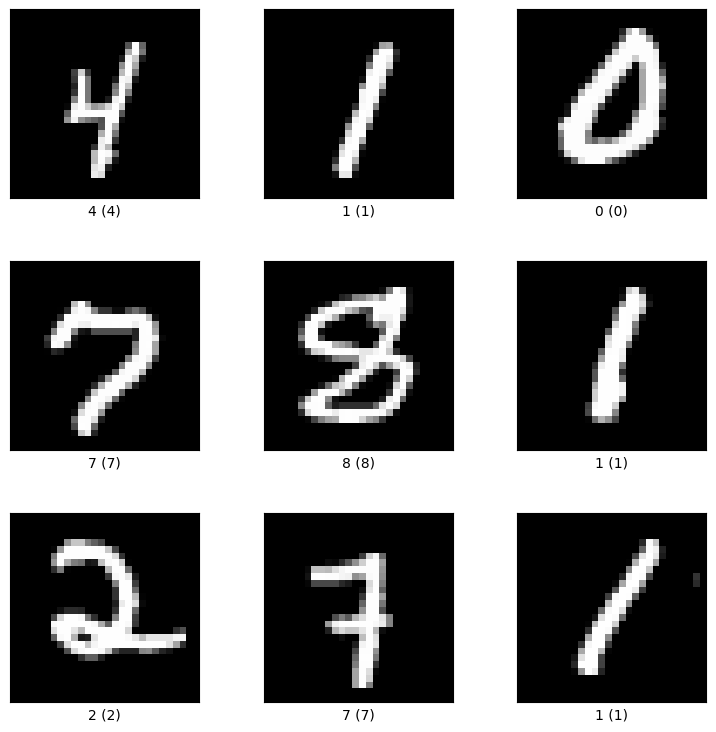

In [6]:
fig = tfds.show_examples(mnist_data_train, data_info)

In [7]:
print("Number of training data items:", data_info.splits["train"].num_examples)
print("Number of testing data items:", data_info.splits["test"].num_examples)

Number of training data items: 60000
Number of testing data items: 10000


## Process the dataset for binary classification

As shown above, the dataset has thousands of images of handwritten numbers with the correct label. Our objective is to find out if the handwritten number is odd or even. This is a binary classification problem that can be solved with logistic regression.

Let us create `True` and `False` labels for odd and even numbers, respectively, and convert the images to Numpy arrays.

In [8]:
labels_true = [0, 2, 4, 6, 8]
labels_false = [1, 3, 5, 7, 9]

In [9]:
train_dataset_images = [example['image'] for example in tfds.as_numpy(mnist_data_train)]
train_dataset_labels = [example['label'] in labels_true for example in tfds.as_numpy(mnist_data_train)]

test_dataset_images = [example['image'] for example in tfds.as_numpy(mnist_data_test)]
test_dataset_labels = [example['label'] in labels_true for example in tfds.as_numpy(mnist_data_test)]

2025-10-21 12:33:44.879665: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-21 12:33:53.994087: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


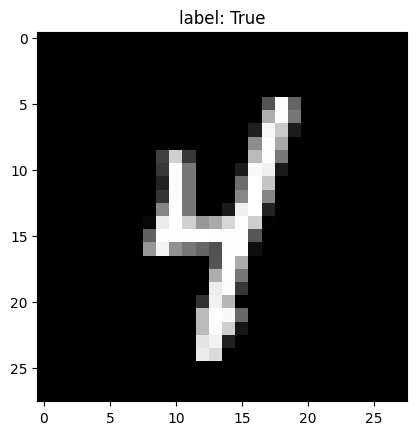

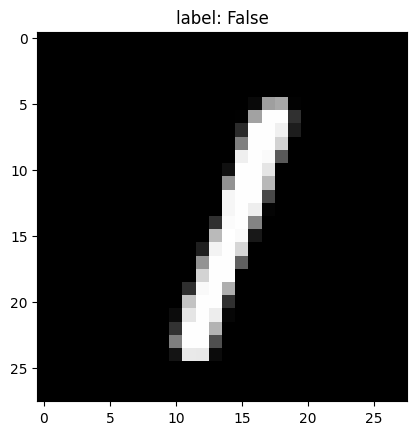

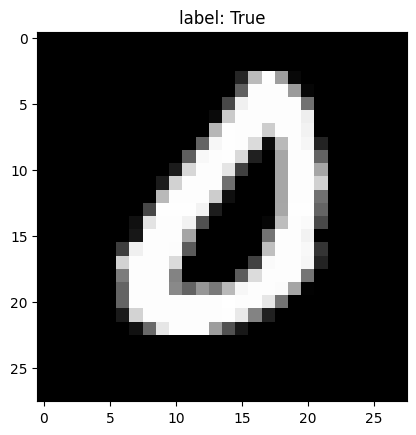

In [10]:
for n in range(3):
    fig = plt.imshow(train_dataset_images[n].squeeze(), cmap='gray')
    plt.title("label: "+str(train_dataset_labels[n]))
    plt.show()

Implementing logistic regression is easier when the images are converted into vectors with normalized values. Hence, let us reshape the image and normalize the color values between zero and one. Then, stack all images into a feature matrix of size (dimension, n_data) and stack all labels into a vector of size (1, n_data).

In [11]:
train_dataset_images_vector = [image.flatten()/255 for image in train_dataset_images]

test_dataset_images_vector = [image.flatten()/255 for image in test_dataset_images]

In [12]:
train_features = np.vstack(train_dataset_images_vector).T
train_labels = np.vstack(train_dataset_labels).T

test_features = np.vstack(test_dataset_images_vector).T
test_labels = np.vstack(test_dataset_labels).T

In [13]:
dim, n_train = train_features.shape
print("The", n_train, "training data items have a dimension of", dim, "and dtype", train_features.dtype)

dim, n_test = test_features.shape
print("The", n_test, "testing data items have a dimension of", dim, "and dtype", test_features.dtype)

The 60000 training data items have a dimension of 784 and dtype float64
The 10000 testing data items have a dimension of 784 and dtype float64


## Implementation of the logistic regression with NumPy

For logistic regression, we need to choose the learning rate for the gradient descent optimization, and initialize the weights and biases as all zeros.

In [14]:
learning_rate = 0.01

In [15]:
initial_weights = np.zeros([dim, 1], dtype=float)
initial_bias = 0.0

Define all functionality of logistic regression, such as the forward and backward pass, the update step of the parameters, and the training and prediction algorithms. The Numpy functions are vectorized and use multithreading by default.

In [16]:
def sigmoid(z):
    return 1.0/(1.0+np.exp(-z))

def forward_propagation(x, w, b):
    z = w.T @ x + b
    a = sigmoid(z)
    return a

def backward_propagation(x, a, y):
    m = x.shape[1]
    j = -np.sum(y * np.log(a) + (1-y) * np.log(1-a)) / m
    dz = a - y
    dw = (x @ dz.T) / m
    db = np.mean(dz)
    return dw, db, j

def update(w, b, dw, db, lr):
    w -= lr * dw
    b -= lr * db
    return w, b

def train(x, y, w, b, lr, n_iter):
    costs = []
    for k in range(n_iter):
        a = forward_propagation(x, w, b)
        dw, db, j = backward_propagation(x, a, y)
        w, b = update(w, b, dw, db, lr)
        costs.append(j)
    return w, b, costs

def predict(x, w, b):
    a = forward_propagation(x, w, b)
    return np.round(a)


## Train the model

Let us train logistic regression on the image dataset, with a fixed number of iterations.

In [17]:
n_iterations = 1000

In [18]:
%%time
weights, bias, cost = train(train_features, train_labels, initial_weights, initial_bias, learning_rate, n_iterations)

CPU times: user 7min 30s, sys: 454 ms, total: 7min 31s
Wall time: 59.3 s


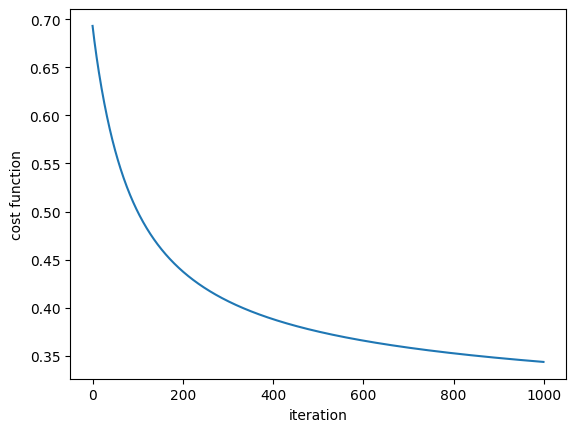

In [19]:
fig = plt.plot(cost)
plt.xlabel('iteration')
plt.ylabel('cost function')
plt.show()

## Perform the prediction

Let us check the accuracy by comparing the predictions with the actual labels, for both the training and testing data set.

In [20]:
%%time
prediction_train = predict(train_features, weights, bias)

CPU times: user 174 ms, sys: 1.84 ms, total: 176 ms
Wall time: 26.6 ms


In [21]:
%%time
prediction_test = predict(test_features, weights, bias)

CPU times: user 27.2 ms, sys: 0 ns, total: 27.2 ms
Wall time: 4.39 ms


In [22]:
correct_train = np.sum(prediction_train == train_labels)
correct_test = np.sum(prediction_test == test_labels)

print("Predicted", correct_train, "items correctly from the", n_train, "training examples:", correct_train/n_train*100, "%")
print("Predicted", correct_test, "items correctly from the", n_test, "testing examples:", correct_test/n_test*100, "%")

Predicted 51318 items correctly from the 60000 training examples: 85.53 %
Predicted 8588 items correctly from the 10000 testing examples: 85.88 %
